# MCN 2026 Pytorch Tutorial

In this tutorial we will cover the basics of building, training, and visualizing a pytorch model.

To keep this tutorial focused, we will concentrate on an RNN - however, many of the principles addressed here transfer to other types of neural networks (CNNs, transformers, etc.).

The toy problem that we will explore here is to train an RNN to generate sinusoids of varying frequencies depending different input configurations (continuous, static, 1-hot).

**Table of Contents**
1. [Dataset](#dataset_section)
2. [Data loader](#dataloader_section)
3. [Model](#model_section)
4. [Lightning Module](#module_section)
5. [Trainer](#trainer_section)
6. [Visualization](#visualization_section)
7. [Comparison with JAX](#troubleshoot_section)


Matt Whiteway, Christina Wang, Hank Grier.

Model based on Sussillo and Barak 2013 Neural Computation

The RNN code is adapted from Piwek et al., (2023) (https://doi.org/10.1371/journal.pcbi.1011555).


Modified by Mira Shi and Bin Wang for MCN 2026.

### Download necessary packages

We will utilize Pytorch Lightning, which enforces a useful modularization of pytorch code and provides a flexible Trainer object that handles learning rate schedulers, logging, etc.

In [ ]:
# For usual pip installation:
# %pip install lightning

In [ ]:
# For our favorite faster uv installation:
!uv pip install --system lightning
!uv pip install tensorboard
!uv pip install plotly

### Import relevant packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
from typing import Any
plt.style.use('dark_background')

<a name='dataset_section'></a>

## Dataset: raw data access layer

Controls how individual data samples are loaded and/or generated, isolating core data logic.
This allows data loading to be reused across different models and independently tested.

**Responsibilities**:
* Loading individual samples from disk, databases, or APIs
* Implementing custom data generation logic
* Basic data transformations and preprocessing (normalization, augmentation)


In [2]:
from torch.utils.data import Dataset

class SinusoidDataset(Dataset):
    """Dataset for cued sinusoid generation: an input indicating output frequency, the the network generates a sinusoid of that frequency"""

    def __init__(
        self,
        seq_length: int = 1000,
        cycles_range: tuple[int, int] = (2, 12),
        step: int = 2,
        n_samples: int = 1000,
        amplitude: float = 1.0,
        noise_level: float = 0.05,
        phase_offset: float = 0.0,
    ):
        self.seq_length = seq_length
        self.n_samples = n_samples
        self.amplitude = amplitude
        self.noise_level = noise_level
        self.phase_offset = phase_offset

        # Generate frequency values based on cycles
        self.cycles = np.arange(cycles_range[0], cycles_range[1] + 1, step)
        self.frequencies = self.cycles / self.seq_length  # Convert cycles to frequency
        self.n_frequencies = len(self.frequencies)

        # Pre-generate all samples
        self.samples = self._generate_samples()

    def create_sine(self, T: int, f: float, A: float = 1.0, phi: float = 0.0) -> np.ndarray:
        """
        Generate a sine wave.

        Parameters:
            T (int): Number of time points (samples).
            f (float): Frequency in cycles per T samples.
            A (float): Amplitude of the sine wave.
            phi (float): Phase offset in radians.

        Returns:
            np.ndarray: The generated sine wave.
        """
        t = np.arange(T)
        return A * np.sin(2 * np.pi * f * t + phi)

    def _generate_samples(self) -> list[tuple[torch.Tensor, torch.Tensor]]:
        """Pre-generate all training samples"""
        samples = []

        for _ in range(self.n_samples):

            # Initialize input and target sequences
            input_seq = torch.zeros(self.seq_length, self.n_frequencies)  # Single input channel for frequency
            target_seq = torch.zeros(self.seq_length, 1)  # Single output channel for sinusoid

            # Randomly select a frequency
            freq_idx = np.random.randint(0, self.n_frequencies)
            frequency = self.frequencies[freq_idx]

            # Set input frequency during cue period
            input_seq[:, freq_idx] = 1

            # Generate sinusoid during generation period
            sinusoid = self.create_sine(self.seq_length, frequency, self.amplitude, self.phase_offset)

            # Add noise if specified
            if self.noise_level > 0:
                noise = np.random.normal(0, self.noise_level, sinusoid.shape)
                sinusoid += noise

            # Set target sinusoid (zero during cue, sinusoid during generation)
            target_seq[:,0] = torch.from_numpy(sinusoid)

            samples.append((input_seq, target_seq))

        return samples

    def __len__(self) -> int:
        return self.n_samples

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.samples[idx]


### STOP: look at dataset outputs

And, if you're feeling thorough, write some unit tests :)

In [3]:
dataset = SinusoidDataset(
    seq_length=500,
    cycles_range=(2, 4),
    step=2,
    n_samples=100,
    amplitude=1.0,
    noise_level=0.05,
    phase_offset=0.0,
)

datapoint type: <class 'tuple'>
first (input) entry: torch.Size([500, 2])
second (output) entry: torch.Size([500, 1])


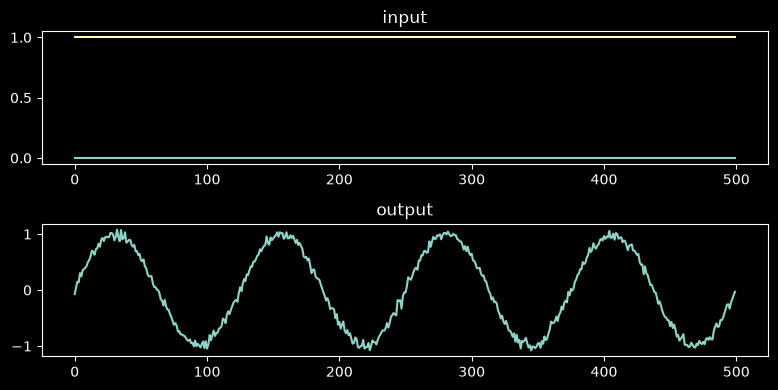

In [4]:
datapoint = dataset[0]

print(f'datapoint type: {type(datapoint)}')
print(f'first (input) entry: {datapoint[0].shape}')
print(f'second (output) entry: {datapoint[1].shape}')

fig, axes = plt.subplots(2, 1, figsize=(8, 4))
axes[0].plot(datapoint[0])
axes[0].set_title("input")
axes[1].plot(datapoint[1])
axes[1].set_title("output")
plt.tight_layout()
plt.show()


datapoint type: <class 'tuple'>
first (input) entry: torch.Size([500, 2])
second (output) entry: torch.Size([500, 1])


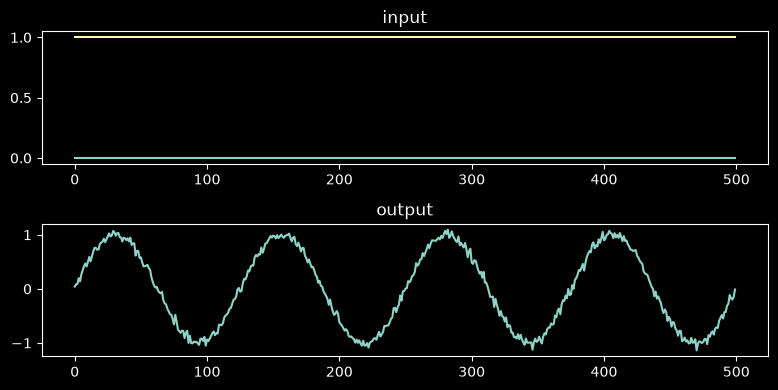

In [5]:
# pick another trial with a different frequency
datapoint = dataset[2]

print(f'datapoint type: {type(datapoint)}')
print(f'first (input) entry: {datapoint[0].shape}')
print(f'second (output) entry: {datapoint[1].shape}')

fig, axes = plt.subplots(2, 1, figsize=(8, 4))
axes[0].plot(datapoint[0])
axes[0].set_title("input")
axes[1].plot(datapoint[1])
axes[1].set_title("output")
plt.tight_layout()
plt.show()

<a name='dataloader_section'></a>

## Dataloaders: feed data to the model

Control how data is organized, batched, and fed to the model during training, validation, and testing.
The Dataset handles _individual_ samples, Dataloader handles _batches_.
This separation allows batching strategies to vary (changing the Dataloader) without changing the underlying data (the Dataset).

**Responsibilities**:
* Handling different phases (train/val/test) with different behaviors
* Batch size configuration and batching logic
* Data shuffling and sampling strategies
* Multi-processing and data loading optimization


In [6]:
from torch.utils.data import DataLoader

def create_data_loaders(
    dataset_params: dict[str, Any],
    train_samples: int = 1000,
    val_samples: int = 10,
    batch_size: int = 10,
) -> tuple[DataLoader, DataLoader]:
    """Create train, validation, and test data loaders"""

    # Create datasets
    train_dataset = SinusoidDataset(n_samples=train_samples, **dataset_params)

    val_dataset = SinusoidDataset(n_samples=val_samples, **dataset_params)

    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    return train_loader, val_loader


# Dataset parameters
train_samples = 500
val_samples = 10
batch_size = 32

dataset_params = {
    'seq_length': 500,
    'cycles_range': (2, 4),  # Even cycles from 2 to 12
    'step': 2,
    'amplitude': 1.0,
    'noise_level': 0.0,
    'phase_offset': 0.0,
}

# Create data loaders
train_loader, val_loader = create_data_loaders(
    dataset_params,
    train_samples=train_samples,
    val_samples=val_samples,
    batch_size=batch_size,
)


### STOP: look at dataloader outputs

In [7]:
batch = next(iter(train_loader))

print(f'batch type: {type(batch)}; batch length: {len(batch)}')
print(f'first (input) entry: {batch[0].shape}    # (batch, seq_length, n_inputs)')
print(f'second (output) entry: {batch[1].shape}  # (batch, seq_length, n_outputs)')

batch type: <class 'list'>; batch length: 2
first (input) entry: torch.Size([32, 500, 2])    # (batch, seq_length, n_inputs)
second (output) entry: torch.Size([32, 500, 1])  # (batch, seq_length, n_outputs)


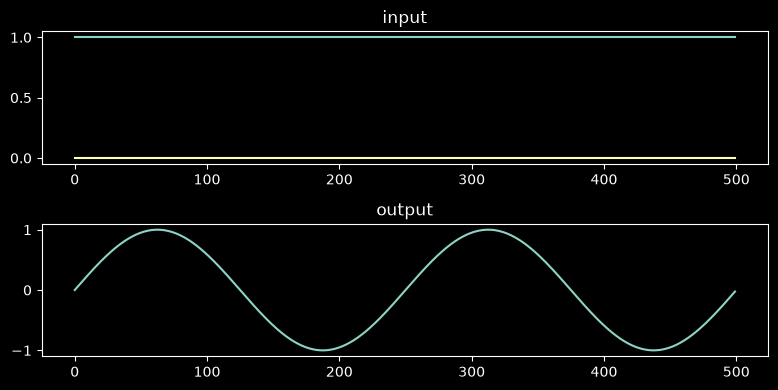

In [8]:
batch_idx = 0

fig, axes = plt.subplots(2, 1, figsize=(8, 4))
axes[0].plot(batch[0][batch_idx])
axes[0].set_title("input")
axes[1].plot(batch[1][batch_idx])
axes[1].set_title("output")
plt.tight_layout()
plt.show()

<a name='model_section'></a>

## Model: core architecture and forward pass

Contains the pure neural network architecture and forward pass logic, focused solely on model computation.

The Model focuses on how the model _computes_, rather than how it is _trained_.
This separation of logic makes it easier to use the same model architecture with different training strategies.

**Responsibilities**:
* Network architecture definition (layers, connections)
* Weight initialization strategies
* Forward pass implementation
* Model-specific helper methods
* Parameter management

What **not** to include:
* Loss function computation (training-specific)
* Optimizer configuration (training-specific)
* Logging and metrics (training-specific)
* Learning rate scheduling (training-specific)


## The mathematical model

The notebook implements a continuous-time recurrent neural network (CTRNN):

$$
h_{t+1}
=
h_t
+
\frac{\Delta t}{\tau}
\left[
-h_t
+
\phi\left(
x_t W_{\mathrm{in}}^{\top}
+
b_{\mathrm{in}}
+
h_t W_{\mathrm{rec}}^{\top}
+
\sigma \epsilon_t
\right)
\right],
$$

followed by

$$
y_t
=
h_{t+1}W_{\mathrm{out}}^{\top}
+
b_{\mathrm{out}}.
$$

Here, $h_t \in \mathbb{R}^{N}$ is the hidden state, $x_t \in \mathbb{R}^{d_{\mathrm{in}}}$ is the input, and $\phi$ is the elementwise hyperbolic tangent in the current experiment.

$$
T=500,
\qquad
N=64,
\qquad
d_{\mathrm{in}}=2,
\qquad
d_{\mathrm{out}}=1,
$$

with $\Delta t=1$, $\tau=10$.

In [9]:
class RNN(nn.Module):
    """Recurrent Neural Network model, discrete time."""

    def __init__(self, params: dict[str, Any]):

        super(RNN, self).__init__()

        # Core parameters
        self.n_rec = params['n_rec']  # number of recurrent neurons
        self.n_inp = params['n_inp']  # input size
        self.n_out = params['n_out']  # output size

        # Noise parameters
        self.noise_sigma = params.get('sigma', 0.0)

        # Initialize layers
        self._init_layers(params)

        self.output_only = False

    def _init_layers(self, params: dict[str, Any]):
        """Initialize network layers"""

        torch.manual_seed(params['seed'])

        # Input layer
        self.inp = nn.Linear(self.n_inp, self.n_rec)

        # Recurrent layer
        Wrec_init = torch.nn.init.kaiming_uniform_(torch.empty((self.n_rec, self.n_rec)))
        self.Wrec = nn.Parameter(Wrec_init)

        # Recurrent nonlinearity
        nonlin_map = {
            'tanh': nn.Tanh(),
            'relu': nn.ReLU(),
            'sigmoid': nn.Sigmoid()
        }
        self.nonlin = nonlin_map.get(params.get('nonlin', 'tanh'))
        if self.nonlin is None:
            raise ValueError(f"Nonlinearity {params.get('nonlin')} not recognized")

        # Output layer
        self.out = nn.Linear(self.n_rec, self.n_out)

    def step(
        self,
        input_ext: torch.Tensor,
        hidden: torch.Tensor,
        noise: torch.Tensor,
        ablations: list | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Run the RNN for one timestep"""

        # The hidden state update equation for discrete RNN:
        hidden = self.nonlin(self.inp(input_ext) + hidden @ self.Wrec.T + noise)

        if ablations is not None:
            hidden[:, :, ablations] = 0

        h = hidden.clone().detach()
        return h, hidden

    def forward(
        self,
        inputs: torch.Tensor,
        h_init: torch.Tensor | None = None,
        output_only: bool | None = None,
    ) -> torch.Tensor:
        """Forward pass through the RNN.

        input shape: (batch_size, seq_length, n_inputs)
        output shape: (batch_size, seq_length, n_outputs)

        output_only: sets whether this returns just the outputs, or also the hidden activities over time
        """
        inputs = inputs.transpose(0, 1) # the rest of the code expects input shape (seq_length, batch_size, n_inputs)

        seq_len, batch_size = inputs.shape[:2]

        # Initialize hidden state
        hidden = torch.zeros((1, batch_size, self.n_rec), device=inputs.device)
        if h_init is not None:
            hidden[:] = h_init[None, :]

        # Storage for outputs and hidden states
        # WARNING: outputs shape is batch first, h is seq_len first!
        h = torch.empty((seq_len, batch_size, self.n_rec), device=inputs.device)
        outputs = torch.empty((batch_size, seq_len, self.n_out), device=inputs.device)

        # Forward pass through time
        for t in range(seq_len):
            # Add noise
            noise = torch.randn(hidden.size(), device=inputs.device) * self.noise_sigma

            # RNN step
            h[t], hidden = self.step(inputs[t], hidden, noise)

            # Compute outputs
            outputs[:, t] = self.out(hidden)

        if output_only is None:
            output_only = self.output_only

        if output_only:
            return outputs

        return outputs, h


class CTRNN(RNN):
    """Recurrent Neural Network model, continuous time."""

    def __init__(self, params):
        super(CTRNN, self).__init__(params)
        self.dt = params['dt']
        self.tau = params['tau']

    def step(self, input_ext, hidden, noise, ablations=None):
        # Write the hidden state update equation for continuous RNN here:
        hidden = hidden + (self.dt / self.tau) * (-hidden + 
                self.nonlin(self.inp(input_ext) + hidden @ self.Wrec.T + noise))
        if ablations is not None:
            hidden[:, :, ablations] = 0
        h = hidden.clone().detach()

        return h, hidden


<a name='module_section'></a>

## Lightning Module: training logic wrapper

Wraps the pure model with all training-related logic (loss computation, logging, etc.).

The Lightning Module maintains clear separation between how the model is trained and how the model computes.
Lightning Benefits: Leverages Lightning's automatic training loop and multi-GPU support.

**Responsibilities**:
* Loss function definition and computation
* Optimizer and learning rate scheduler configuration
* Training, validation, and test step implementations
* Metric computation and logging
* Gradient clipping and other training tricks
* Model checkpointing logic
* Custom training behaviors and hooks



## Without Lightning

In ordinary PyTorch, you write the complete training loop yourself:

```python
model = RNN(model_params)
model = model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(num_epochs):
    model.train()

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

    model.eval()

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            val_loss = criterion(outputs, targets)
```

You would also manually handle:

- Moving model and data to CPU/GPU
- Averaging losses
- Logging
- Checkpoints
- Learning-rate schedulers
- Distributed training
- Early stopping

## With Lightning

You provide the batch-level recipe:

```python
def training_step(...):
    ...

def validation_step(...):
    ...

def configure_optimizers(...):
    ...
```

Then Lightning supplies the outer loop:

```python
trainer.fit(model, train_loader, val_loader)
```

In [10]:
class CustomLoss(nn.Module):
    """Custom loss function for RNN"""

    def __init__(self, magnitude_penalty_weight=0.01):
        super(CustomLoss, self).__init__()
        self.mse_loss = nn.MSELoss()
        self.magnitude_penalty_weight = magnitude_penalty_weight

    def forward(self, outputs, targets):
        # Calculate MSE loss
        mse = self.mse_loss(outputs, targets)
        # Calculate magnitude penalty (e.g., L2 norm of predictions)
        # Using .pow(2).mean() for L2-like penalty on magnitude
        magnitude_penalty = torch.mean(outputs.pow(2))
        # Combine losses
        total_loss = mse + self.magnitude_penalty_weight * magnitude_penalty
        return total_loss


class RNNLightning(pl.LightningModule):
    """PyTorch Lightning module for RNN."""

    def __init__(self, model_params: dict[str, Any], train_params: dict[str, Any]):
        super().__init__()
        self.save_hyperparameters()

        # Model parameters
        self.model_params = model_params
        self.train_params = train_params

        # Initialize RNN
        if model_params['continuous']:
            self.rnn = CTRNN(model_params)
        else:
            self.rnn = RNN(model_params)

        # Loss function
        if model_params['loss'] == 'mse':
            self.criterion = nn.MSELoss(reduction='mean')
        elif model_params['loss'] == 'custom':
            self.criterion = CustomLoss()
        else:
            raise ValueError(f"Loss function {model_params['loss']} not supported")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass"""
        # x shape: [batch, seq_len, n_freqs]
        output = self.rnn(x, output_only=True)
        return output

    def training_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        """Training step"""
        inputs, targets = batch
        outputs = self.forward(inputs)
        loss = self.criterion(outputs, targets)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        """Validation step"""
        inputs, targets = batch
        outputs = self.forward(inputs)
        loss = self.criterion(outputs, targets)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        """Configure optimizer"""
        optimizer_name = self.train_params.get('optimizer', 'adam').lower()
        lr = self.train_params.get('learning_rate', 1e-3)

        if optimizer_name == 'adam':
            optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        elif optimizer_name == 'rmsprop':
            optimizer = torch.optim.RMSprop(self.parameters(), lr=lr)
        else:
            raise ValueError(f"Optimizer {optimizer_name} not supported")

        return optimizer


In [11]:
# Model parameters
model_params = {
    'n_inp': 2,        # number of frequency bins
    'n_rec': 64,       # number of recurrent units
    'n_out': 1,        # sinusoid output
    'nonlin': 'tanh',  # recurrent nonlinearity
    'sigma': 0.0001,   # gaussian noise level for hidden units
    'seed': 8,         # random seed for initializing weights (try 0 then 8)
    'loss': 'mse',     # 'mse' or 'custom'
    # continuous model parameters
    'continuous': True,
    'dt': 1,
    'tau': 10,
}

# Training parameters
train_params = {
    'optimizer': 'adam',
    'learning_rate': 1e-4,
}

# Initialize model
model = RNNLightning(model_params, train_params)

### STOP: make sure we can pass data through the model

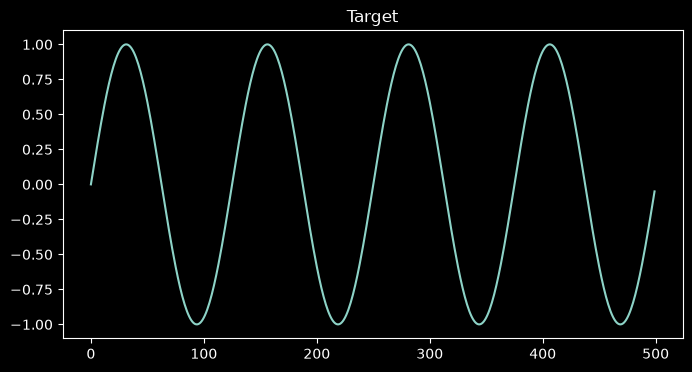

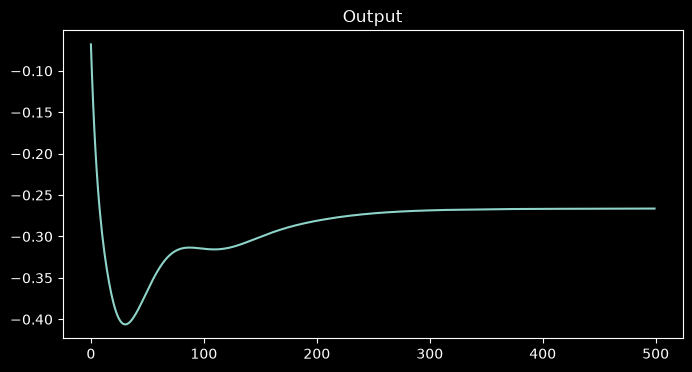

In [17]:
inputs, targets = train_loader.dataset[1]
outputs = model(inputs.unsqueeze(0))

plt.figure(figsize=(8, 4))
plt.plot(targets)
plt.title('Target')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(outputs.detach().cpu().numpy()[0, :, 0])
plt.title('Output')
plt.show()

<a name='trainer_section'></a>

## Trainer

Manages the overall training process, hardware utilization, and experiment configuration.

**Responsibilities**:
* Training loop execution (epochs, steps, early stopping)
* Logging configuration and integration
* Checkpoint saving and loading
* Gradient accumulation strategies
* Profiling and debugging tools
* Mixed precision training
* Hardware management (CPU/GPU/TPU selection, multi-device training)


In [22]:
# Create trainer
trainer = pl.Trainer(max_epochs=50, accelerator='gpu',  # 'cpu' or 'gpu'
    check_val_every_n_epoch=1,  # evaluate val data at the end of each training epoch
    logger=pl.loggers.TensorBoardLogger('logs'))

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### Set up logging with tensorboard

In [23]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [20]:
# Launch tensorboard before launching training (happens in next cell).
# If you receive a 403 error, be sure to enable all cookies for this site in your browser.
# To see the losses during training, select TIME SERIES and hit the refresh button (circle arrow) on the top right.

# when running outside of colab, you can launch tensorboard from the command line similarly:
# tensorboard --logdir log
# you will then see a message pop up telling you that tensorboard is running locally on a particular port;
# click the link to open tensorboard in your browser

%tensorboard --logdir logs

In [24]:
# Train model
trainer.fit(model, train_loader, val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.

  | Name      | Type    | Params | Mode  | FLOPs
------------------------------------------------------
0 | rnn       | CTRNN   | 4.4 K  | train | 0    
1 | criterion | MSELoss | 0      | train | 0    
------------------------------------------------------
4.4 K     Trainable params
0         Non-trainable params
4.4 K     Total params
0.017     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 49: 100%|██████████| 16/16 [00:05<00:00,  3.17it/s, v_num=1, val_loss=0.000541, train_loss=0.000557]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 16/16 [00:05<00:00,  3.17it/s, v_num=1, val_loss=0.000541, train_loss=0.000557]


### Check trained model

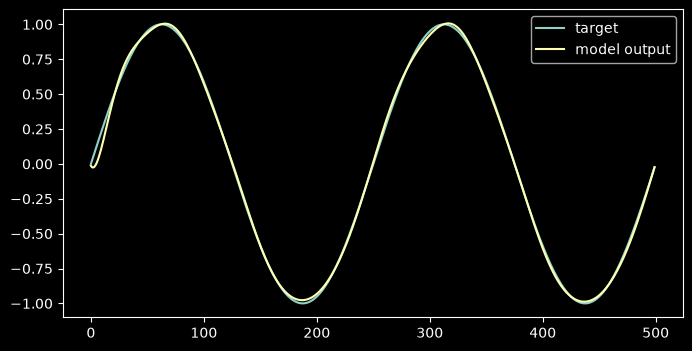

In [25]:
inputs, targets = train_loader.dataset[0]
outputs = model(inputs.unsqueeze(0))  # unsqueeze adds "batch" dim

plt.figure(figsize=(8, 4))
plt.plot(targets, label='target')
plt.plot(outputs.detach().cpu().numpy()[0, :, 0], label='model output')
plt.legend()
plt.show()

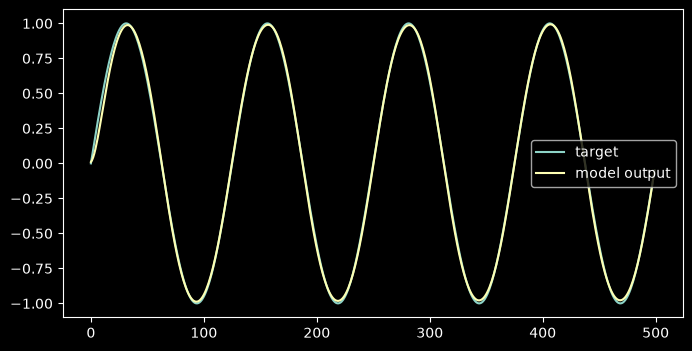

In [26]:
# try a trial with different frequency
inputs, targets = train_loader.dataset[1]
outputs = model(inputs.unsqueeze(0))  # unsqueeze adds "batch" dim

plt.figure(figsize=(8, 4))
plt.plot(targets, label='target')
plt.plot(outputs.detach().cpu().numpy()[0, :, 0], label='model output')
plt.legend()
plt.show()

<a name='visualization_section'></a>

## Visualization

In [28]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [29]:
import seaborn as sns
from sklearn.decomposition import PCA

Epoch 8:  81%|████████▏ | 13/16 [05:43<01:19,  0.04it/s, v_num=0, val_loss=0.409, train_loss=0.426]


### Visualize hidden activity

In [33]:
# a single example trial
inputs, targets = train_loader.dataset[1]

with torch.no_grad():
   outputs, h = model.rnn(inputs.unsqueeze(0), output_only=False)  # unsqueeze adds "batch" dim

In [34]:
h.shape # (time, trial, neuron)

torch.Size([500, 1, 64])

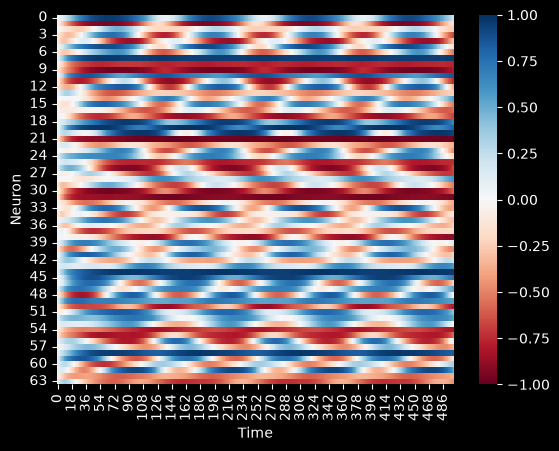

In [35]:
# visualize hidden activity on this trial
# x=time, y=neuron

ax = sns.heatmap(h[:, 0].T, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel('Time')
ax.set_ylabel('Neuron')
plt.show()

In [36]:
# another example trial with different frequency
inputs, targets = train_loader.dataset[4]
with torch.no_grad():
   outputs, h = model.rnn(inputs.unsqueeze(0), output_only=False)  # unsqueeze adds "batch" dim

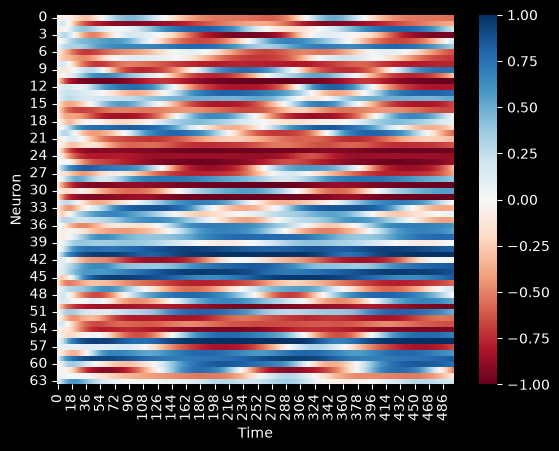

In [37]:
# x=time, y=neuron
ax = sns.heatmap(h[:, 0].T, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xlabel('Time')
ax.set_ylabel('Neuron')
plt.show()

In [39]:
!pip install fastcluster

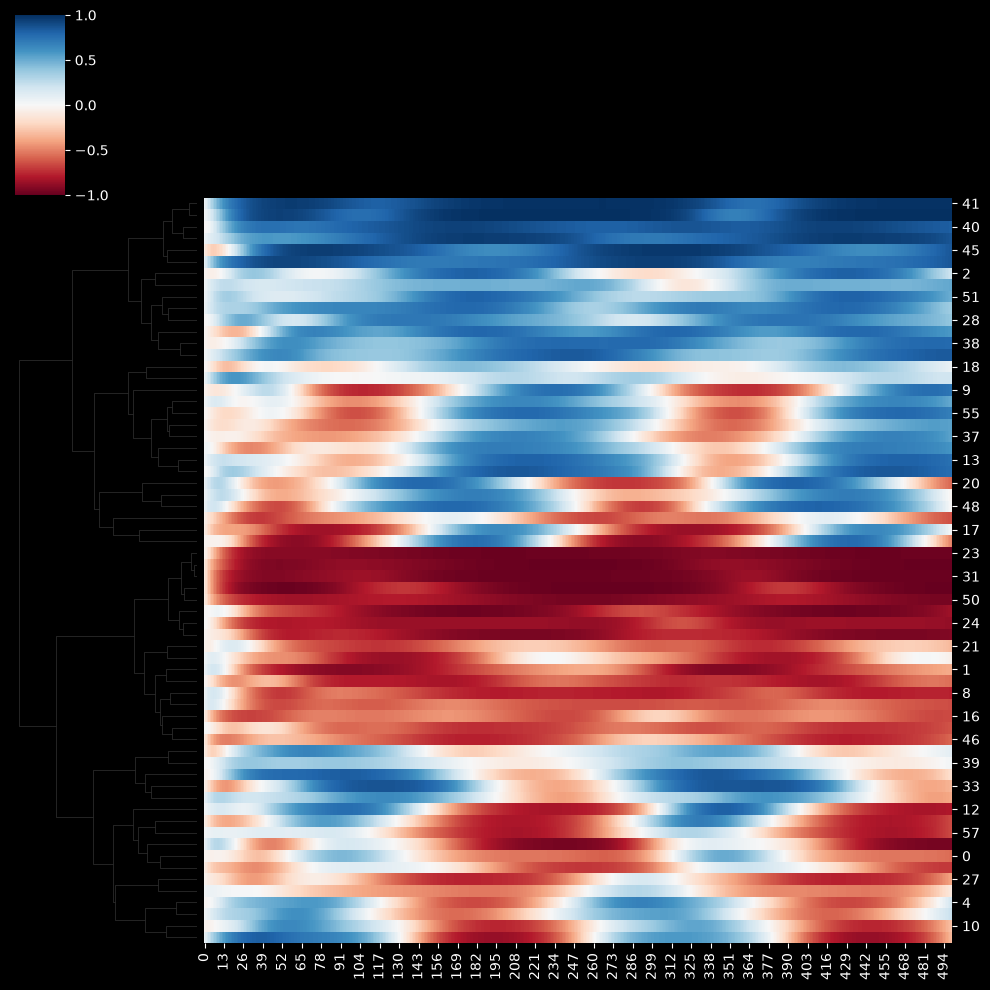

In [40]:
# clustering neurons based on activity on this trial
sns.clustermap(h[:, 0].T, col_cluster=False, cmap='RdBu', vmin=-1, vmax=1)

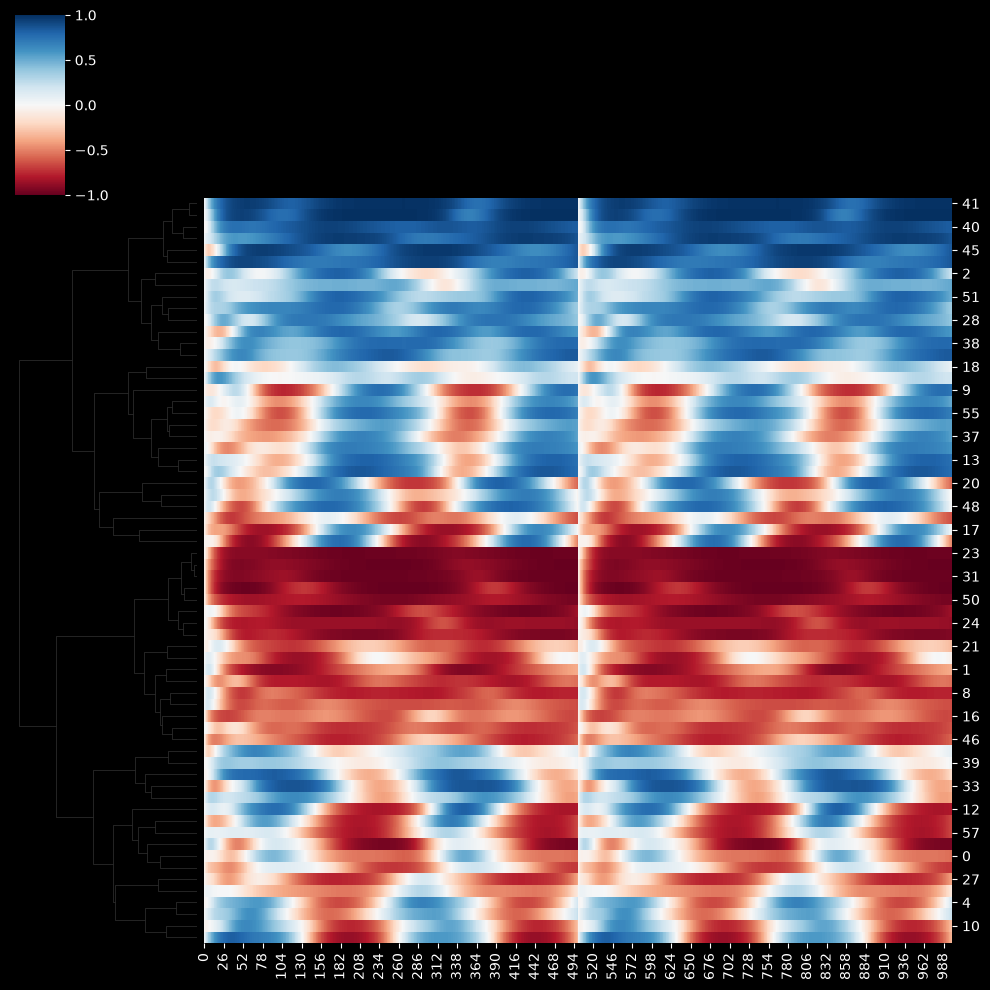

In [41]:
# using both frequencies, cluster all the neurons
inputs1, _ = train_loader.dataset[0]
inputs2, _ = train_loader.dataset[4]
inputs = torch.stack([inputs1, inputs2], dim=0) # combine these two trials
with torch.no_grad():
    outputs, h = model.rnn(inputs, output_only=False)  # unsqueeze adds "batch" dim
h = h.transpose(0, 1).reshape(-1, h.shape[2])
sns.clustermap(h.T, col_cluster=False, cmap='RdBu', vmin=-1, vmax=1)

### PCA

#### across both frequencies, all time points

In [42]:
batch = next(iter(train_loader)) # we will just use a random batch of trials

# h is (time, trial, neuron)
inputs, targets = batch
with torch.no_grad():
    outputs, h = model.rnn(inputs, output_only=False)  # unsqueeze adds "batch" dim

In [43]:
h.shape

torch.Size([500, 32, 64])

In [44]:
n_timesteps, n_trials, n_neurons = h.shape
X = h.reshape(-1, n_neurons)

pca = PCA()
pcs = pca.fit_transform(X)

In [45]:
# X should be neuron x sample (so cov matrix is neuron x neuron)
def compute_pr(X):
    C = np.cov(X)
    pr = np.trace(C)**2 / np.trace(C@C)
    return pr

def compute_pr_pca(pca):
    eigenvals = pca.explained_variance_
    return np.sum(eigenvals)**2 / np.sum(eigenvals**2)

Text(0.5, 1.0, 'PR = 3.0')

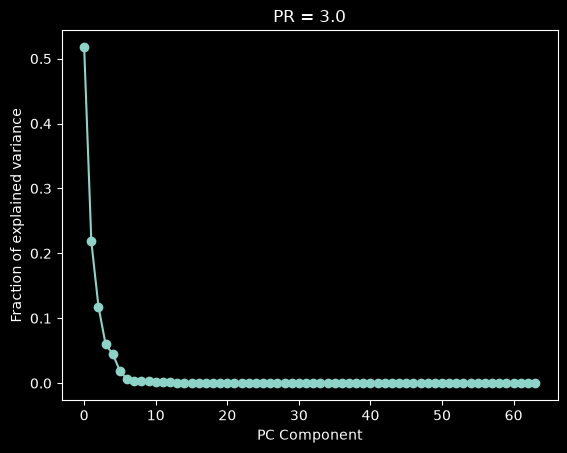

In [46]:
fig, ax = plt.subplots()
ax.plot(pca.explained_variance_ratio_, '-o')
ax.set(xlabel='PC Component', ylabel='Fraction of explained variance')
ax.set_title(f'PR = {compute_pr_pca(pca):.1f}')

In [47]:
# top 3 PCs explain __% variance
pca.explained_variance_ratio_[:3].sum()

np.float64(0.8539859532974987)

<Axes: >

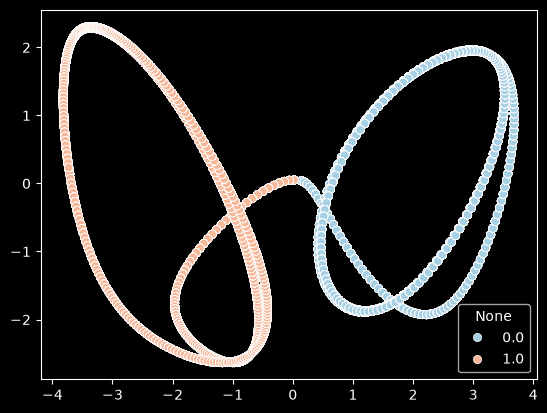

In [53]:
# color by frequency
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1],
               hue=inputs[:, :, 0].T.flatten(), palette='RdBu_r')

<Axes: >

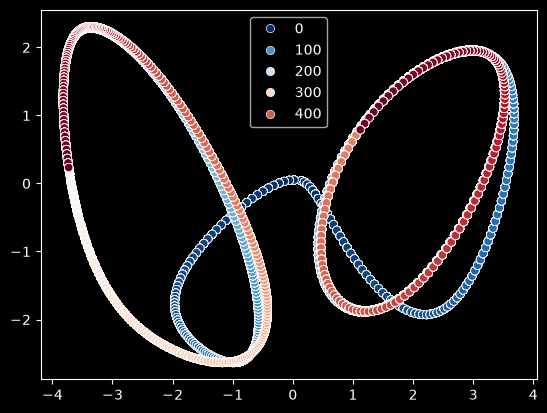

In [52]:
# color by time
ts = np.zeros(h.shape[:2])
ts[:] = np.arange(n_timesteps)[:, None]
ts = ts.flatten()

sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1],
               hue=ts, palette='RdBu_r')

<Axes: >

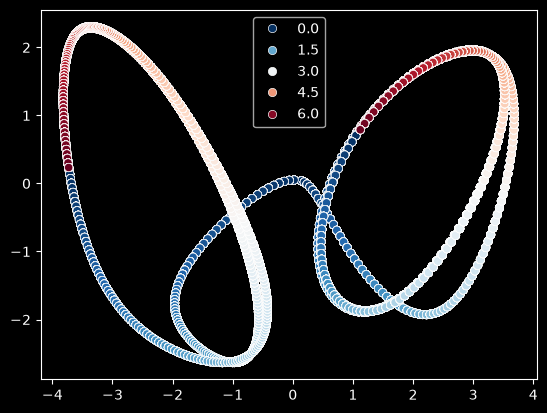

In [51]:
# color by phase
frequencies = train_loader.dataset.frequencies[inputs[:, :, 1].numpy().astype(int)]
ts = np.zeros(h.shape[:2])
ts[:] = np.arange(n_timesteps)[:, None]
phases = (np.arange(n_timesteps) * frequencies * 2 * np.pi) % (2*np.pi)
sns.scatterplot(x=pcs[:, 0], y=pcs[:, 1],hue=phases.T.flatten(), palette='RdBu_r')

In [ ]:
# for interactive 3D plot
# if using local jupyter: can just do %matplotlib widget

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Scatter3d(
    x=pcs[:, 0],
    y=pcs[:, 1],
    z=pcs[:, 2],
    mode='markers',
    marker=dict(
        size=5,
        color=phases.T.flatten(),
        colorscale='Viridis',
        colorbar=dict(title='Phase')
    )
)])

fig.show()

In [ ]:
# what you can run if you are on local jupyter
# %matplotlib widget
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(pcs[:, 0], pcs[:, 1], pcs[:, 2], c=phases.T.flatten(), cmap='viridis')

### weights

In [54]:
Wrec = model.rnn.Wrec.detach().numpy()
Win = model.rnn.inp.weight.detach().numpy()
Wout = model.rnn.out.weight.detach().numpy()

<Axes: >

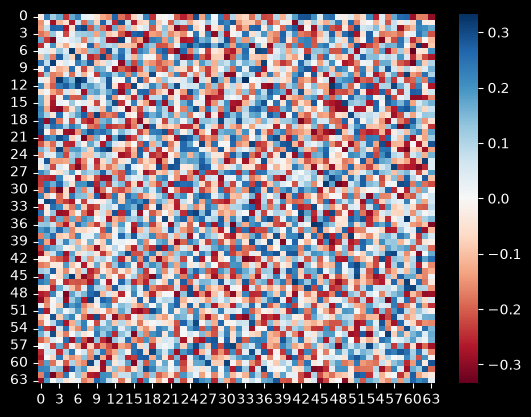

In [55]:
sns.heatmap(Wrec, cmap='RdBu', center=0)

<Axes: >

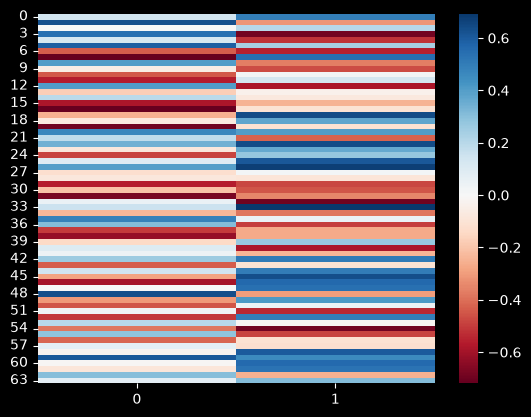

In [56]:
sns.heatmap(Win, cmap='RdBu', center=0)

In [57]:
# the two input weight vectors are near orthogonal (would occur just by chance)
from scipy.spatial.distance import cosine
1 - cosine(Win[:, 0], Win[:, 1]) # cosine similarity

np.float32(-0.014059663)

<Axes: >

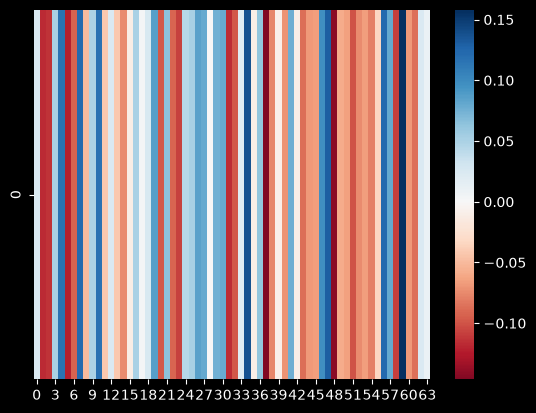

In [58]:
sns.heatmap(Wout, cmap='RdBu', center=0)

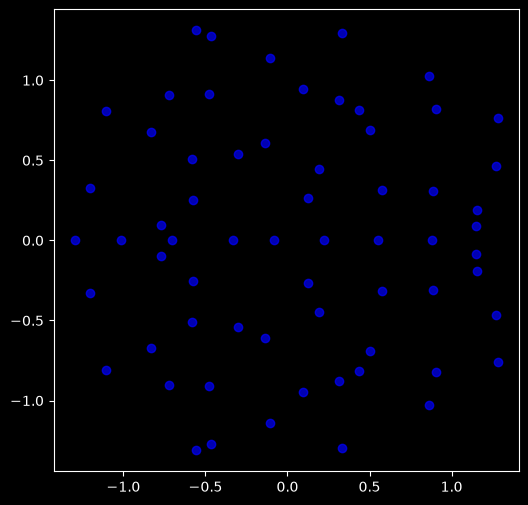

In [59]:
eigvals, eigvecs = np.linalg.eig(Wrec)
plt.figure(figsize=(6, 6))
plt.scatter(eigvals.real, eigvals.imag, color='blue', alpha=0.7)

<a name='troubleshoot_section'></a>

## Troubleshoot

*What to do if my network's training?*

Ask ChatGPT!

Potential things to try:
* Check your code! There might a bug somewhere
	+ Make sure the gradients are flowing correctly
	+ Check data format (float v. int, torch.tensor v. numpy.ndarray), shape
* Look into what your current model is doing!
	+ Is the gradient too small? Too large?
	+ What is the model outputting (0? a constant value?) Is the hidden activity all 0 or stuck at some fixed point?
* Different learning rate, optimizer
	+ Use a learning rate scheduler
	+ Make sure the loss function is appropriate for the task (e.g. cross-entropy for categorical output, MSE for continuous output)
* Change model size
* Just train longer...? (sometimes loss can plateau for a long time before it decreases)
	+ Try multiple random seeds, different initializations
* Try different architectures
	+ E.g. instead of vanilla RNN, try LSTM/GRU
* Regularization (especially if the model is overfitting)
* Make the task easier
	+ Make the task shorter
	+ Simplify the inputs
	+ Use a curriculum (like training an animal :)
	+ Make the loss more informative (e.g. instead of just outputting a final choice at the end, also output other intermediate variables during the trial)


<a name='extension_section'></a>

## Fun extensions

Changing the task
* Vary the number of possible frequencies. How does the dimensionality of the representation vary?
* Change the input from one-hot to a continuous value that indicates a continuous range of frequencies. Is this easier or harder?
* Make the input transient (perhaps the network can only start outputting the sine, at phase 0, after the input is off)
* The target frequency could change over time, the output needs to adapt to it instantaneously
* Rhythmic timing task: the input is a sine wave that stops after some period, the output should match the input and continue the sine wave (even after input offset) (see https://www.biorxiv.org/content/10.1101/2024.05.24.595797v1)

Changing the model
* Try different model architectures: low-rank RNN? E-I (respect Dale's law)? Different weight initializations?

Understanding the network better
* Test generalization to novel frequencies (you might want to change how the input frequency is indicated)
+ For one-hot input, what if you activate multiple input units at various levels?
* Try fixed point analysis (see https://github.com/mattgolub/fixed-point-finder)

**Be creative and have fun!**

<a name='jax_comparison_section'></a>

## PyTorch and JAX: the same CTRNN in two execution models

This section separates three questions that are often conflated:

1. **Numerical correctness:** do the two implementations compute the same forward map and gradients?
2. **Statistical efficiency:** given the same initialization and batches, do they learn at the same rate per optimizer update?
3. **Computational efficiency:** how much compilation time and steady-state wall-clock time does each implementation require?

We implement the CTRNN directly in JAX. For biophysical neuroscience models written in JAX, relevant packages include [Jaxley](https://jaxley.readthedocs.io/) and [BrainPy](https://brainpy.readthedocs.io/).

The JAX implementation below uses [`jax.lax.scan`](https://docs.jax.dev/en/latest/_autosummary/jax.lax.scan.html) for recurrence and `jax.jit` for just-in-time compilation. To keep the notebook dependency-light, it uses JAX's bundled example Adam optimizer. In a larger project, [Optax](https://optax.readthedocs.io/) is the standard optimizer library.

### 1. Common mathematical model and comparison protocol

For a batch of input vectors $x_t$, the deterministic CTRNN is

$$
\begin{aligned}
z_t &= x_t W_{\mathrm{in}}^\top + b_{\mathrm{in}}
      + h_t W_{\mathrm{rec}}^\top,\\
h_{t+1} &= h_t + \frac{\Delta t}{\tau}
\left[-h_t + \tanh(z_t)\right],\\
y_t &= h_{t+1}W_{\mathrm{out}}^\top+b_{\mathrm{out}}.
\end{aligned}
$$

Here $h_t\in\mathbb{R}^{N}$ is the recurrent state. We initially set process noise to zero so that exact numerical parity is testable. Both implementations accept an externally supplied noise tensor, so a stochastic comparison can later use identical noise samples.

A fair comparison requires identical:

- parameter arrays, not merely identical seed values;
- data and batch order;
- floating-point precision;
- optimizer hyperparameters;
- hardware platform;
- timing boundaries, including synchronization of asynchronous accelerator work.

In [61]:
!pip install jax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 2.2 MB/s  0:00:01 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 MB 1.0 MB/s  0:00:46m0:00:010m00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 1.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [jax]3/4 [jax]ib]


In [63]:
import os
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

import copy
import time
from typing import Callable

import jax
import jax.numpy as jnp
from jax.example_libraries import optimizers as jax_optimizers
import pandas as pd
from IPython.display import display

print(f'PyTorch version: {torch.__version__}')
print(f'JAX version:     {jax.__version__}')
print(f'PyTorch CUDA available: {torch.cuda.is_available()}')
print(f'JAX devices: {jax.devices()}')

# CPU is the reproducible classroom default. Set this to 'auto' to use a GPU
# only when both frameworks can see one, or to 'gpu' to require a common GPU.
COMPARISON_PLATFORM = 'auto'  # choices: 'cpu', 'auto', 'gpu'

jax_gpu_devices = [device for device in jax.devices() if device.platform == 'gpu']
torch_has_gpu = torch.cuda.is_available()

if COMPARISON_PLATFORM == 'auto':
    comparison_platform = 'gpu' if torch_has_gpu and jax_gpu_devices else 'cpu'
elif COMPARISON_PLATFORM == 'gpu':
    if not (torch_has_gpu and jax_gpu_devices):
        raise RuntimeError('Both PyTorch and JAX must see a GPU for a GPU comparison.')
    comparison_platform = 'gpu'
elif COMPARISON_PLATFORM == 'cpu':
    comparison_platform = 'cpu'
else:
    raise ValueError("COMPARISON_PLATFORM must be 'cpu', 'auto', or 'gpu'.")

comparison_torch_device = torch.device(
    'cuda' if comparison_platform == 'gpu' else 'cpu'
)
comparison_jax_device = next(
    device for device in jax.devices() if device.platform == comparison_platform
)

print(f'Common comparison platform: {comparison_platform}')
print(f'PyTorch device: {comparison_torch_device}')
print(f'JAX device: {comparison_jax_device}')

PyTorch version: 2.13.0
JAX version:     0.10.2
PyTorch CUDA available: False
JAX devices: [CpuDevice(id=0)]
Common comparison platform: cpu
PyTorch device: cpu
JAX device: cpu:0


### 2. Matched PyTorch and JAX implementations

The PyTorch implementation uses an ordinary Python loop, which is natural in eager mode. The JAX implementation represents the recurrence with `lax.scan`, whose first return value is the carried hidden state and whose second return value stores the time series.

The parameter convention is shared exactly:

- `W_in`: `(hidden, input)`;
- `W_rec`: `(hidden, hidden)`;
- `W_out`: `(output, hidden)`;
- biases: one-dimensional arrays.

In [64]:
class TorchCTRNNComparison(nn.Module):
    """Clean CTRNN used only for the matched framework comparison."""

    def __init__(
        self,
        parameters: dict[str, np.ndarray],
        dt: float,
        tau: float,
    ):
        super().__init__()
        self.dt = float(dt)
        self.tau = float(tau)

        # The names match the keys in the JAX parameter PyTree.
        self.W_in = nn.Parameter(torch.as_tensor(parameters['W_in']).clone())
        self.b_in = nn.Parameter(torch.as_tensor(parameters['b_in']).clone())
        self.W_rec = nn.Parameter(torch.as_tensor(parameters['W_rec']).clone())
        self.W_out = nn.Parameter(torch.as_tensor(parameters['W_out']).clone())
        self.b_out = nn.Parameter(torch.as_tensor(parameters['b_out']).clone())

    def forward(
        self,
        inputs: torch.Tensor,
        noise: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """Return outputs [batch, time, output] and states [time, batch, hidden]."""
        inputs_time_first = inputs.transpose(0, 1)
        batch_size = inputs.shape[0]
        hidden_size = self.W_rec.shape[0]
        hidden = torch.zeros(
            batch_size,
            hidden_size,
            dtype=inputs.dtype,
            device=inputs.device,
        )

        outputs = []
        hidden_states = []
        alpha = self.dt / self.tau

        for time_index, input_t in enumerate(inputs_time_first):
            preactivation = (
                input_t @ self.W_in.T
                + self.b_in
                + hidden @ self.W_rec.T
            )
            if noise is not None:
                preactivation = preactivation + noise[time_index]

            hidden = hidden + alpha * (-hidden + torch.tanh(preactivation))
            output_t = hidden @ self.W_out.T + self.b_out

            outputs.append(output_t)
            hidden_states.append(hidden)

        return torch.stack(outputs, dim=1), torch.stack(hidden_states, dim=0)


def jax_ctrnn_forward(
    parameters: dict[str, jax.Array],
    inputs: jax.Array,
    dt: float,
    tau: float,
    noise: jax.Array | None = None,
) -> tuple[jax.Array, jax.Array]:
    """JAX CTRNN with the same conventions as TorchCTRNNComparison."""
    inputs_time_first = jnp.swapaxes(inputs, 0, 1)
    batch_size = inputs.shape[0]
    hidden_size = parameters['W_rec'].shape[0]
    hidden0 = jnp.zeros((batch_size, hidden_size), dtype=inputs.dtype)
    alpha = jnp.asarray(dt / tau, dtype=inputs.dtype)

    if noise is None:
        noise = jnp.zeros(
            (inputs.shape[1], batch_size, hidden_size),
            dtype=inputs.dtype,
        )

    def recurrent_step(hidden, scan_inputs):
        input_t, noise_t = scan_inputs
        preactivation = (
            input_t @ parameters['W_in'].T
            + parameters['b_in']
            + hidden @ parameters['W_rec'].T
            + noise_t
        )
        hidden_next = hidden + alpha * (
            -hidden + jnp.tanh(preactivation)
        )
        output_t = hidden_next @ parameters['W_out'].T + parameters['b_out']
        return hidden_next, (output_t, hidden_next)

    _, (outputs_time_first, hidden_time_first) = jax.lax.scan(
        recurrent_step,
        hidden0,
        (inputs_time_first, noise),
    )
    outputs = jnp.swapaxes(outputs_time_first, 0, 1)
    return outputs, hidden_time_first


def jax_ctrnn_loss(
    parameters: dict[str, jax.Array],
    inputs: jax.Array,
    targets: jax.Array,
    dt: float,
    tau: float,
) -> jax.Array:
    outputs, _ = jax_ctrnn_forward(parameters, inputs, dt=dt, tau=tau)
    return jnp.mean((outputs - targets) ** 2)

In [65]:
# Generate one set of parameter arrays with the original PyTorch initializer,
# then copy the arrays into both comparison models. Matching seed values alone
# would not be sufficient because frameworks use different random generators.
comparison_model_params = dict(model_params)
comparison_model_params['sigma'] = 0.0

reference_initialization = CTRNN(comparison_model_params)
shared_initial_parameters = {
    'W_in': reference_initialization.inp.weight.detach().cpu().numpy().copy(),
    'b_in': reference_initialization.inp.bias.detach().cpu().numpy().copy(),
    'W_rec': reference_initialization.Wrec.detach().cpu().numpy().copy(),
    'W_out': reference_initialization.out.weight.detach().cpu().numpy().copy(),
    'b_out': reference_initialization.out.bias.detach().cpu().numpy().copy(),
}

comparison_dt = float(comparison_model_params['dt'])
comparison_tau = float(comparison_model_params['tau'])

initial_jax_parameters = {name: jax.device_put(jnp.asarray(value), comparison_jax_device)
    for name, value in shared_initial_parameters.items()}

print({name: value.shape for name, value in shared_initial_parameters.items()})

{'W_in': (64, 2), 'b_in': (64,), 'W_rec': (64, 64), 'W_out': (1, 64), 'b_out': (1,)}


### 3. Numerical parity: forward map, gradients, and one SGD update

We first compare the programs before training. A disagreement here would invalidate any later speed or learning comparison.

The relative gradient error for a parameter tensor $g$ is

$$
\frac{\lVert g_{\mathrm{Torch}}-g_{\mathrm{JAX}}\rVert_2}
{\max(\lVert g_{\mathrm{Torch}}\rVert_2,
      \lVert g_{\mathrm{JAX}}\rVert_2,10^{-12})}.
$$

Small differences remain because floating-point reductions and operation ordering are not bitwise identical.

In [66]:
parity_inputs = torch.stack([
    train_loader.dataset[index][0] for index in range(8)
]).to(dtype=torch.float32)
parity_targets = torch.stack([
    train_loader.dataset[index][1] for index in range(8)
]).to(dtype=torch.float32)

parity_torch_inputs = parity_inputs.to(comparison_torch_device)
parity_torch_targets = parity_targets.to(comparison_torch_device)
parity_jax_inputs = jax.device_put(
    jnp.asarray(parity_inputs.numpy()),
    comparison_jax_device,
)
parity_jax_targets = jax.device_put(
    jnp.asarray(parity_targets.numpy()),
    comparison_jax_device,
)

parity_torch_model = TorchCTRNNComparison(
    shared_initial_parameters,
    dt=comparison_dt,
    tau=comparison_tau,
).to(comparison_torch_device)

with torch.no_grad():
    parity_torch_outputs, parity_torch_hidden = parity_torch_model(
        parity_torch_inputs
    )
parity_jax_outputs, parity_jax_hidden = jax_ctrnn_forward(
    initial_jax_parameters,
    parity_jax_inputs,
    dt=comparison_dt,
    tau=comparison_tau,
)
parity_jax_outputs.block_until_ready()

output_max_error = np.max(np.abs(
    parity_torch_outputs.detach().cpu().numpy()
    - np.asarray(jax.device_get(parity_jax_outputs))
))
hidden_max_error = np.max(np.abs(
    parity_torch_hidden.detach().cpu().numpy()
    - np.asarray(jax.device_get(parity_jax_hidden))
))

print(f'maximum output error: {output_max_error:.3e}')
print(f'maximum hidden-state error: {hidden_max_error:.3e}')

maximum output error: 4.470e-07
maximum hidden-state error: 5.811e-07


In [67]:
# PyTorch gradients
parity_torch_model.zero_grad(set_to_none=True)
parity_torch_outputs, _ = parity_torch_model(parity_torch_inputs)
parity_torch_loss = F.mse_loss(parity_torch_outputs, parity_torch_targets)
parity_torch_loss.backward()
parity_torch_gradients = {
    name: parameter.grad.detach().cpu().numpy().copy()
    for name, parameter in parity_torch_model.named_parameters()
}

# JAX gradients
parity_jax_loss, parity_jax_gradients = jax.value_and_grad(jax_ctrnn_loss)(
    initial_jax_parameters,
    parity_jax_inputs,
    parity_jax_targets,
    comparison_dt,
    comparison_tau,
)
parity_jax_loss.block_until_ready()

parity_rows = []
for name in shared_initial_parameters:
    torch_gradient = parity_torch_gradients[name]
    jax_gradient = np.asarray(jax.device_get(parity_jax_gradients[name]))
    denominator = max(
        np.linalg.norm(torch_gradient),
        np.linalg.norm(jax_gradient),
        1e-12,
    )
    parity_rows.append({
        'parameter': name,
        'relative gradient error': np.linalg.norm(
            torch_gradient - jax_gradient
        ) / denominator,
        'maximum absolute error': np.max(np.abs(
            torch_gradient - jax_gradient
        )),
    })

print(f'PyTorch loss: {parity_torch_loss.item():.9f}')
print(f'JAX loss:     {float(parity_jax_loss):.9f}')
display(pd.DataFrame(parity_rows))

PyTorch loss: 0.612563133
JAX loss:     0.612563133


,parameter,relative gradient error,maximum absolute error
0,W_in,1.104827e-06,1.117587e-07
1,b_in,7.532378e-07,8.940697e-08
2,W_rec,9.426885e-07,1.192093e-07
3,W_out,7.307635e-07,2.384186e-07
4,b_out,6.989252e-07,2.086163e-07


In [68]:
# Verify one elementary stochastic-gradient-descent update as well.
parity_learning_rate = 1e-3

with torch.no_grad():
    for name, parameter in parity_torch_model.named_parameters():
        parameter -= parity_learning_rate * parameter.grad

after_sgd_jax_parameters = jax.tree_util.tree_map(
    lambda parameter, gradient: parameter - parity_learning_rate * gradient,
    initial_jax_parameters,
    parity_jax_gradients,
)

update_rows = []
for name, parameter in parity_torch_model.named_parameters():
    torch_value = parameter.detach().cpu().numpy()
    jax_value = np.asarray(jax.device_get(after_sgd_jax_parameters[name]))
    denominator = max(np.linalg.norm(torch_value), np.linalg.norm(jax_value), 1e-12)
    update_rows.append({
        'parameter': name,
        'relative parameter error after SGD': np.linalg.norm(
            torch_value - jax_value
        ) / denominator,
    })

display(pd.DataFrame(update_rows))

,parameter,relative parameter error after SGD
0,W_in,0.000000e+00
1,b_in,0.000000e+00
2,W_rec,2.280538e-09
3,W_out,1.358247e-08
4,b_out,0.000000e+00


### 4. Matched training experiment

The two optimizers receive the same initialization and the same sequence of mini-batches. The default experiment uses 50 updates, which is fast enough for a live tutorial and already learns this two-frequency task. Increase `comparison_steps` for a more converged comparison.

We measure JAX compilation separately. The first call to a jitted function traces and compiles the computation; subsequent calls reuse the executable as long as relevant shapes and dtypes remain unchanged.

In [ ]:
comparison_steps = 50
comparison_batch_size = 32
comparison_learning_rate = 1e-3
comparison_batch_seed = 2026

all_inputs_np = np.stack([
    train_loader.dataset[index][0].numpy()
    for index in range(len(train_loader.dataset))
]).astype(np.float32)
all_targets_np = np.stack([
    train_loader.dataset[index][1].numpy()
    for index in range(len(train_loader.dataset))
]).astype(np.float32)

comparison_rng = np.random.default_rng(comparison_batch_seed)
comparison_batch_indices = comparison_rng.integers(
    0,
    len(train_loader.dataset),
    size=(comparison_steps, comparison_batch_size),
)
comparison_input_batches_np = all_inputs_np[comparison_batch_indices]
comparison_target_batches_np = all_targets_np[comparison_batch_indices]

print(f'input batches:  {comparison_input_batches_np.shape}')
print(f'target batches: {comparison_target_batches_np.shape}')

In [ ]:
def synchronize_torch(device: torch.device) -> None:
    """Wait for pending PyTorch accelerator work, if any."""
    if device.type == 'cuda':
        torch.cuda.synchronize(device)


def train_torch_comparison(
    initial_parameters: dict[str, np.ndarray],
    input_batches: np.ndarray,
    target_batches: np.ndarray,
) -> tuple[TorchCTRNNComparison, np.ndarray, float]:
    model = TorchCTRNNComparison(
        initial_parameters,
        dt=comparison_dt,
        tau=comparison_tau,
    ).to(comparison_torch_device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=comparison_learning_rate,
        betas=(0.9, 0.999),
        eps=1e-8,
    )

    inputs = torch.as_tensor(input_batches, device=comparison_torch_device)
    targets = torch.as_tensor(target_batches, device=comparison_torch_device)
    losses = np.empty(len(input_batches), dtype=np.float64)

    synchronize_torch(comparison_torch_device)
    start = time.perf_counter()
    model.train()
    for step in range(len(input_batches)):
        optimizer.zero_grad(set_to_none=True)
        outputs, _ = model(inputs[step])
        loss = F.mse_loss(outputs, targets[step])
        loss.backward()
        optimizer.step()
        losses[step] = float(loss.detach())
    synchronize_torch(comparison_torch_device)
    elapsed = time.perf_counter() - start

    return model, losses, elapsed


trained_torch_model, torch_training_losses, torch_training_seconds = (
    train_torch_comparison(
        shared_initial_parameters,
        comparison_input_batches_np,
        comparison_target_batches_np,
    )
)

print(f'PyTorch final loss: {torch_training_losses[-1]:.6f}')
print(f'PyTorch training time: {torch_training_seconds:.3f} s')

In [ ]:
jax_optimizer_init, jax_optimizer_update, jax_get_parameters = (
    jax_optimizers.adam(
        step_size=comparison_learning_rate,
        b1=0.9,
        b2=0.999,
        eps=1e-8)
)


@jax.jit
def jax_train_step(step, optimizer_state, inputs, targets):
    parameters = jax_get_parameters(optimizer_state)
    loss, gradients = jax.value_and_grad(jax_ctrnn_loss)(
        parameters,
        inputs,
        targets,
        comparison_dt,
        comparison_tau,
    )
    optimizer_state = jax_optimizer_update(
        step,
        gradients,
        optimizer_state,
    )
    return optimizer_state, loss


comparison_input_batches_jax = jax.device_put(
    jnp.asarray(comparison_input_batches_np),
    comparison_jax_device,
)
comparison_target_batches_jax = jax.device_put(
    jnp.asarray(comparison_target_batches_np),
    comparison_jax_device,
)

# Compile using a disposable optimizer state, then reset to the common initialization.
compile_state = jax_optimizer_init(initial_jax_parameters)
compile_start = time.perf_counter()
_, compile_loss = jax_train_step(
    jnp.asarray(0, dtype=jnp.int32),
    compile_state,
    comparison_input_batches_jax[0],
    comparison_target_batches_jax[0],
)
compile_loss.block_until_ready()
jax_compile_seconds = time.perf_counter() - compile_start

jax_optimizer_state = jax_optimizer_init(initial_jax_parameters)
jax_losses_device = []
training_start = time.perf_counter()
for step in range(comparison_steps):
    jax_optimizer_state, loss = jax_train_step(
        jnp.asarray(step, dtype=jnp.int32),
        jax_optimizer_state,
        comparison_input_batches_jax[step],
        comparison_target_batches_jax[step],
    )
    jax_losses_device.append(loss)

jax_losses_device[-1].block_until_ready()
jax_training_seconds = time.perf_counter() - training_start
jax_training_losses = np.asarray(jax.device_get(jnp.stack(jax_losses_device)))
trained_jax_parameters = jax_get_parameters(jax_optimizer_state)

print(f'JAX final loss: {jax_training_losses[-1]:.6f}')
print(f'JAX compilation plus first update: {jax_compile_seconds:.3f} s')
print(f'JAX steady-state training time: {jax_training_seconds:.3f} s')

In [ ]:
plt.figure(figsize=(7, 4))
plt.semilogy(torch_training_losses, label='PyTorch eager')
plt.semilogy(jax_training_losses, linestyle='--', label='JAX jit + lax.scan')
plt.xlabel('optimizer update')
plt.ylabel('mean squared error')
plt.title('Matched learning curves')
plt.legend()
plt.show()

training_summary = pd.DataFrame([
    {
        'implementation': 'PyTorch eager',
        'initial loss': torch_training_losses[0],
        'final loss': torch_training_losses[-1],
        'compile seconds': 0.0,
        'training seconds': torch_training_seconds,
        'milliseconds per update': 1e3 * torch_training_seconds / comparison_steps,
    },
    {
        'implementation': 'JAX jit + lax.scan',
        'initial loss': jax_training_losses[0],
        'final loss': jax_training_losses[-1],
        'compile seconds': jax_compile_seconds,
        'training seconds': jax_training_seconds,
        'milliseconds per update': 1e3 * jax_training_seconds / comparison_steps,
    },
])
display(training_summary)

### 5. Do the learned networks implement similar neural dynamics?

Identical loss curves do not imply identical parameters because nonlinear network training is nonconvex and floating-point differences can accumulate. For neuroscience, it is often more informative to compare observable and dynamical properties:

- task mean squared error;
- hidden trajectories in a common principal-component basis;
- participation ratio of hidden activity;
- recurrent weight spectrum.

The principal components below are fit jointly to both networks, so their trajectories are shown in the same coordinate system.

In [ ]:
# Select one noiseless example of each input frequency.
evaluation_pairs = []
for frequency_index in range(comparison_model_params['n_inp']):
    for sample_inputs, sample_targets in train_loader.dataset:
        if int(torch.argmax(sample_inputs[0])) == frequency_index:
            evaluation_pairs.append((sample_inputs, sample_targets))
            break

comparison_eval_inputs_np = np.stack([
    pair[0].numpy() for pair in evaluation_pairs
]).astype(np.float32)
comparison_eval_targets_np = np.stack([
    pair[1].numpy() for pair in evaluation_pairs
]).astype(np.float32)

comparison_eval_inputs_torch = torch.as_tensor(
    comparison_eval_inputs_np,
    device=comparison_torch_device,
)
trained_torch_model.eval()
with torch.no_grad():
    torch_eval_outputs, torch_eval_hidden = trained_torch_model(
        comparison_eval_inputs_torch
    )

torch_eval_outputs_np = torch_eval_outputs.detach().cpu().numpy()
torch_eval_hidden_np = torch_eval_hidden.detach().cpu().numpy()

comparison_eval_inputs_jax = jax.device_put(
    jnp.asarray(comparison_eval_inputs_np),
    comparison_jax_device,
)
jax_eval_outputs, jax_eval_hidden = jax_ctrnn_forward(
    trained_jax_parameters,
    comparison_eval_inputs_jax,
    dt=comparison_dt,
    tau=comparison_tau,
)
jax_eval_outputs.block_until_ready()
jax_eval_outputs_np = np.asarray(jax.device_get(jax_eval_outputs))
jax_eval_hidden_np = np.asarray(jax.device_get(jax_eval_hidden))

figure, axes = plt.subplots(
    len(evaluation_pairs),
    1,
    figsize=(8, 3 * len(evaluation_pairs)),
    sharex=True,
)
axes = np.atleast_1d(axes)
for frequency_index, axis in enumerate(axes):
    axis.plot(
        comparison_eval_targets_np[frequency_index, :, 0],
        label='target',
    )
    axis.plot(
        torch_eval_outputs_np[frequency_index, :, 0],
        label='PyTorch',
    )
    axis.plot(
        jax_eval_outputs_np[frequency_index, :, 0],
        linestyle='--',
        label='JAX',
    )
    cycles = train_loader.dataset.cycles[frequency_index]
    axis.set_title(f'{cycles} cycles per trial')
    axis.set_ylabel('output')
axes[-1].set_xlabel('time step')
axes[0].legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA


def centered_participation_ratio(hidden_activity: np.ndarray) -> float:
    """Participation ratio of the centered neuron-by-neuron covariance."""
    samples_by_neurons = hidden_activity.reshape(-1, hidden_activity.shape[-1])
    samples_by_neurons = samples_by_neurons - samples_by_neurons.mean(
        axis=0,
        keepdims=True,
    )
    covariance = np.cov(samples_by_neurons, rowvar=False)
    eigenvalues = np.linalg.eigvalsh(covariance)
    denominator = np.sum(eigenvalues ** 2)
    return float(np.sum(eigenvalues) ** 2 / denominator) if denominator > 0 else 0.0


def fraction_in_common_pcs(activity: np.ndarray, pca: PCA) -> float:
    """Fraction of activity energy captured by the displayed common PCs."""
    centered = activity.reshape(-1, activity.shape[-1]) - pca.mean_
    scores = centered @ pca.components_.T
    total_energy = np.sum(centered ** 2)
    return float(np.sum(scores ** 2) / total_energy) if total_energy > 0 else 0.0


torch_activity = torch_eval_hidden_np.reshape(-1, torch_eval_hidden_np.shape[-1])
jax_activity = jax_eval_hidden_np.reshape(-1, jax_eval_hidden_np.shape[-1])
common_pca = PCA(n_components=3)
common_pca.fit(np.concatenate([torch_activity, jax_activity], axis=0))

torch_pcs = common_pca.transform(torch_activity).reshape(
    torch_eval_hidden_np.shape[0],
    torch_eval_hidden_np.shape[1],
    3,
)
jax_pcs = common_pca.transform(jax_activity).reshape(
    jax_eval_hidden_np.shape[0],
    jax_eval_hidden_np.shape[1],
    3,
)

plt.figure(figsize=(7, 6))
for frequency_index in range(len(evaluation_pairs)):
    plt.plot(
        torch_pcs[:, frequency_index, 0],
        torch_pcs[:, frequency_index, 1],
        label=f'PyTorch, frequency {frequency_index}',
    )
    plt.plot(
        jax_pcs[:, frequency_index, 0],
        jax_pcs[:, frequency_index, 1],
        linestyle='--',
        label=f'JAX, frequency {frequency_index}',
    )
plt.xlabel('common PC 1')
plt.ylabel('common PC 2')
plt.title('Hidden trajectories in a common PCA basis')
plt.legend()
plt.show()

trained_torch_Wrec = trained_torch_model.W_rec.detach().cpu().numpy()
trained_jax_Wrec = np.asarray(jax.device_get(trained_jax_parameters['W_rec']))
torch_recurrent_eigenvalues = np.linalg.eigvals(trained_torch_Wrec)
jax_recurrent_eigenvalues = np.linalg.eigvals(trained_jax_Wrec)

plt.figure(figsize=(6, 6))
plt.scatter(
    torch_recurrent_eigenvalues.real,
    torch_recurrent_eigenvalues.imag,
    alpha=0.65,
    label='PyTorch',
)
plt.scatter(
    jax_recurrent_eigenvalues.real,
    jax_recurrent_eigenvalues.imag,
    marker='x',
    label='JAX',
)
plt.axvline(0, linewidth=0.5)
plt.axhline(0, linewidth=0.5)
plt.xlabel('real part')
plt.ylabel('imaginary part')
plt.title('Recurrent weight spectra')
plt.legend()
plt.show()

scientific_summary = pd.DataFrame([
    {
        'implementation': 'PyTorch',
        'evaluation MSE': np.mean(
            (torch_eval_outputs_np - comparison_eval_targets_np) ** 2
        ),
        'participation ratio': centered_participation_ratio(
            torch_eval_hidden_np
        ),
        'W_rec spectral radius': np.max(np.abs(torch_recurrent_eigenvalues)),
        'fraction in first 3 common PCs': fraction_in_common_pcs(
            torch_eval_hidden_np,
            common_pca,
        ),
    },
    {
        'implementation': 'JAX',
        'evaluation MSE': np.mean(
            (jax_eval_outputs_np - comparison_eval_targets_np) ** 2
        ),
        'participation ratio': centered_participation_ratio(
            jax_eval_hidden_np
        ),
        'W_rec spectral radius': np.max(np.abs(jax_recurrent_eigenvalues)),
        'fraction in first 3 common PCs': fraction_in_common_pcs(
            jax_eval_hidden_np,
            common_pca,
        ),
    },
])
display(scientific_summary)

### 6. Runtime benchmark: compile time versus steady-state time

Accelerator operations can be asynchronous. The benchmark therefore synchronizes PyTorch CUDA work and calls `block_until_ready()` for JAX. Data are moved to the device before timing.

We time blocks of several updates and report the median time per update and the interquartile range (IQR). This is more stable than reporting a single call. Compilation is not included in the steady-state JAX number.

If JAX has compile cost $C$, PyTorch eager takes $t_P$ per update, and compiled JAX takes $t_J<t_P$, the approximate break-even number of updates is

$$
n_\star = \frac{C}{t_P-t_J}.
$$

This quantity tells us whether compilation is worthwhile for a particular experiment.

For a publication-quality GPU benchmark, run the two frameworks in separate fresh processes. In one shared notebook they can compete for allocator caches and device memory. Peak-memory comparison is therefore left as an exercise rather than reported as a misleading single-process number.

In [ ]:
benchmark_repeats = 5
benchmark_steps_per_repeat = 5
benchmark_warmup_steps = 2
benchmark_inputs_np = comparison_input_batches_np[0]
benchmark_targets_np = comparison_target_batches_np[0]


def benchmark_torch_eager() -> np.ndarray:
    model = TorchCTRNNComparison(
        shared_initial_parameters,
        dt=comparison_dt,
        tau=comparison_tau,
    ).to(comparison_torch_device)
    optimizer = torch.optim.Adam(model.parameters(), lr=comparison_learning_rate)
    inputs = torch.as_tensor(benchmark_inputs_np, device=comparison_torch_device)
    targets = torch.as_tensor(benchmark_targets_np, device=comparison_torch_device)

    def update():
        optimizer.zero_grad(set_to_none=True)
        outputs, _ = model(inputs)
        loss = F.mse_loss(outputs, targets)
        loss.backward()
        optimizer.step()
        return loss

    for _ in range(benchmark_warmup_steps):
        update()
    synchronize_torch(comparison_torch_device)

    seconds_per_update = []
    for _ in range(benchmark_repeats):
        synchronize_torch(comparison_torch_device)
        start = time.perf_counter()
        for _ in range(benchmark_steps_per_repeat):
            update()
        synchronize_torch(comparison_torch_device)
        elapsed = time.perf_counter() - start
        seconds_per_update.append(elapsed / benchmark_steps_per_repeat)

    return np.asarray(seconds_per_update)


def benchmark_jax_jit() -> np.ndarray:
    optimizer_state = jax_optimizer_init(initial_jax_parameters)
    inputs = jax.device_put(jnp.asarray(benchmark_inputs_np), comparison_jax_device)
    targets = jax.device_put(jnp.asarray(benchmark_targets_np), comparison_jax_device)

    for step in range(benchmark_warmup_steps):
        optimizer_state, loss = jax_train_step(
            jnp.asarray(step, dtype=jnp.int32),
            optimizer_state,
            inputs,
            targets,
        )
    loss.block_until_ready()

    seconds_per_update = []
    step = benchmark_warmup_steps
    for _ in range(benchmark_repeats):
        start = time.perf_counter()
        for _ in range(benchmark_steps_per_repeat):
            optimizer_state, loss = jax_train_step(
                jnp.asarray(step, dtype=jnp.int32),
                optimizer_state,
                inputs,
                targets,
            )
            step += 1
        loss.block_until_ready()
        elapsed = time.perf_counter() - start
        seconds_per_update.append(elapsed / benchmark_steps_per_repeat)

    return np.asarray(seconds_per_update)


torch_benchmark_seconds = benchmark_torch_eager()
jax_benchmark_seconds = benchmark_jax_jit()


def benchmark_row(name: str, values: np.ndarray, compile_seconds: float):
    q25, median, q75 = np.percentile(values, [25, 50, 75])
    return {
        'implementation': name,
        'median ms/update': 1e3 * median,
        'IQR ms/update': 1e3 * (q75 - q25),
        'compile seconds': compile_seconds,
    }


benchmark_summary = pd.DataFrame([
    benchmark_row('PyTorch eager', torch_benchmark_seconds, 0.0),
    benchmark_row('JAX jit + lax.scan', jax_benchmark_seconds, jax_compile_seconds),
])
display(benchmark_summary)

median_torch = float(np.median(torch_benchmark_seconds))
median_jax = float(np.median(jax_benchmark_seconds))
if median_jax < median_torch:
    break_even_updates = jax_compile_seconds / (median_torch - median_jax)
    print(f'Estimated JAX compilation break-even: {break_even_updates:.1f} updates')
else:
    print('JAX is not faster in this configuration, so there is no positive break-even point.')

### 7. Neuroscience bonus: local state Jacobians

Automatic differentiation is also useful after training. For a fixed input $x_t$, define the one-step state map $F(h_t,x_t)=h_{t+1}$. Its Jacobian

$$
J_t = \frac{\partial F(h_t,x_t)}{\partial h_t}
$$

characterizes local expansion, contraction, and rotational modes around the trajectory. We compute it with `torch.func.jacrev` and `jax.jacrev`, then compare the spectral radii of the independently trained networks.

In [ ]:
from torch.func import jacrev as torch_jacrev

jacobian_input_time = comparison_eval_inputs_np.shape[1] // 2
jacobian_state_index = jacobian_input_time - 1
jacobian_trial = 0

# PyTorch Jacobian for the trained PyTorch network.
torch_hidden_point = torch.as_tensor(
    torch_eval_hidden_np[jacobian_state_index, jacobian_trial],
    device=comparison_torch_device,
)
torch_input_point = torch.as_tensor(
    comparison_eval_inputs_np[jacobian_trial, jacobian_input_time],
    device=comparison_torch_device,
)


def torch_state_map(hidden):
    preactivation = (
        torch_input_point @ trained_torch_model.W_in.T
        + trained_torch_model.b_in
        + hidden @ trained_torch_model.W_rec.T
    )
    return hidden + (comparison_dt / comparison_tau) * (
        -hidden + torch.tanh(preactivation)
    )


torch_state_jacobian = torch_jacrev(torch_state_map)(
    torch_hidden_point
).detach().cpu().numpy()

# JAX Jacobian for the trained JAX network.
jax_hidden_point = jax_eval_hidden[jacobian_state_index, jacobian_trial]
jax_input_point = comparison_eval_inputs_jax[jacobian_trial, jacobian_input_time]


def jax_state_map(hidden):
    preactivation = (
        jax_input_point @ trained_jax_parameters['W_in'].T
        + trained_jax_parameters['b_in']
        + hidden @ trained_jax_parameters['W_rec'].T
    )
    return hidden + (comparison_dt / comparison_tau) * (
        -hidden + jnp.tanh(preactivation)
    )


jax_state_jacobian = np.asarray(jax.device_get(
    jax.jacrev(jax_state_map)(jax_hidden_point)
))

torch_jacobian_eigenvalues = np.linalg.eigvals(torch_state_jacobian)
jax_jacobian_eigenvalues = np.linalg.eigvals(jax_state_jacobian)

plt.figure(figsize=(6, 6))
plt.scatter(
    torch_jacobian_eigenvalues.real,
    torch_jacobian_eigenvalues.imag,
    alpha=0.65,
    label='PyTorch',
)
plt.scatter(
    jax_jacobian_eigenvalues.real,
    jax_jacobian_eigenvalues.imag,
    marker='x',
    label='JAX',
)
plt.axvline(0, linewidth=0.5)
plt.axhline(0, linewidth=0.5)
plt.xlabel('real part')
plt.ylabel('imaginary part')
plt.title(f'Local state Jacobian spectra at t={jacobian_input_time}')
plt.legend()
plt.show()

jacobian_summary = pd.DataFrame([
    {
        'implementation': 'PyTorch',
        'Jacobian spectral radius': np.max(np.abs(torch_jacobian_eigenvalues)),
    },
    {
        'implementation': 'JAX',
        'Jacobian spectral radius': np.max(np.abs(jax_jacobian_eigenvalues)),
    },
])
display(jacobian_summary)

### 8. Interpretation and exercises

**PyTorch eager** emphasizes direct, stateful execution. It is usually easy to inspect, modify, and debug. PyTorch Lightning adds training infrastructure, logging, checkpointing, and hardware management.

**JAX** emphasizes pure functions and transformations. Explicit parameters and optimizer state make the program more algebraic, while `jit`, `lax.scan`, `vmap`, and automatic differentiation are particularly useful for repeated simulations, parameter sweeps, and dynamical analyses.

A timing result is not a universal ranking. It depends on sequence length, recurrent width, batch size, device, precision, compiler version, and whether compilation is amortized over enough updates.

Suggested extensions:

1. Sweep sequence length $T$, recurrent width $N$, and batch size $B$ separately.
2. Repeat the benchmark on a common GPU and report peak memory.
3. Generate one NumPy noise tensor and pass it to both forward functions.
4. Compare eager PyTorch, `torch.compile`, unjitted JAX, and jitted JAX.
5. Use `jax.vmap` or `torch.vmap` to parallelize a parameter sweep.
6. Track the state-Jacobian spectral radius throughout a trial.
7. Test whether the two trained networks generalize similarly to frequencies absent from training.